# Prática 01: EDA e Feature Engineering com GenAI
### Unidade 1 · Ciclo de Vida de ML e Feature Engineering
**Disciplina:** Machine Learning, Pós-Graduação em IA Generativa e Aplicações com LLMs · PUC Minas
**Professor:** Maurício Rodrigues da Silva

---

## Como usar este notebook

Este notebook é o seu **guia teórico e prático** da Unidade 1. Cada seção começa com uma explicação
curta (a mesma vista em aula, com as mesmas imagens dos slides) seguida do código que implementa o
que acabou de ser explicado. Não pule direto para o código: a ideia é que você nunca fique em dúvida
sobre o *porquê* de cada passo, não só o *como*.

**Roteiro da tarefa (individual):**
1. Carregar o dataset e fazer a primeira inspeção
2. Analisar distribuições (histograma, média e mediana)
3. Detectar outliers com o método IQR
4. Ler o heatmap de correlação
5. Fazer Feature Engineering com um prompt de IA Generativa (+ Checklist do Auditor)
6. Tratar dados ausentes, codificar categorias e escalonar variáveis
7. Separar treino e teste corretamente

⚠️ **Nesta tarefa vocês não vão treinar nenhum modelo ainda.** O objetivo é dominar bem cada etapa
do processo de EDA e Feature Engineering. Treinar e comparar modelos é o assunto da próxima aula
(Aula 2, Regressão) em diante, quando vocês já terão as bases de pré-processamento bem firmes.

📝 **Documente os prompts que você usar em cada etapa com IA, isso vira o seu *prompt log*, exigido
na entrega do Trabalho Orientado.**

---

## Dicionário de dados: Telco Customer Churn

O dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) tem 7.043 linhas (uma por cliente) e 21 colunas:

| Feature | Descrição |
|---|---|
| `customerID` | Identificador único do cliente (não é uma feature preditiva). |
| `gender` | Gênero do cliente (`Male`/`Female`). |
| `SeniorCitizen` | Indica se o cliente é idoso (1) ou não (0). |
| `Partner` | Se o cliente tem cônjuge/parceiro(a) (`Yes`/`No`). |
| `Dependents` | Se o cliente tem dependentes (`Yes`/`No`). |
| `tenure` | Número de meses que o cliente permanece na empresa. |
| `PhoneService` | Se o cliente tem serviço de telefone (`Yes`/`No`). |
| `MultipleLines` | Se o cliente tem múltiplas linhas telefônicas (`Yes`/`No`/`No phone service`). |
| `InternetService` | Provedor de internet do cliente (`DSL`/`Fiber optic`/`No`). |
| `OnlineSecurity` | Se o cliente tem serviço de segurança online (`Yes`/`No`/`No internet service`). |
| `OnlineBackup` | Se o cliente tem serviço de backup online (`Yes`/`No`/`No internet service`). |
| `DeviceProtection` | Se o cliente tem proteção de dispositivo (`Yes`/`No`/`No internet service`). |
| `TechSupport` | Se o cliente tem suporte técnico (`Yes`/`No`/`No internet service`). |
| `StreamingTV` | Se o cliente tem serviço de streaming de TV (`Yes`/`No`/`No internet service`). |
| `StreamingMovies` | Se o cliente tem serviço de streaming de filmes (`Yes`/`No`/`No internet service`). |
| `Contract` | Tipo de contrato do cliente (`Month-to-month`/`One year`/`Two year`). |
| `PaperlessBilling` | Se o cliente usa fatura digital, sem papel (`Yes`/`No`). |
| `PaymentMethod` | Forma de pagamento (`Electronic check`/`Mailed check`/`Bank transfer (automatic)`/`Credit card (automatic)`). |
| `MonthlyCharges` | Valor cobrado mensalmente do cliente. |
| `TotalCharges` | Valor total cobrado do cliente ao longo de todo o período de contrato. |
| `Churn` | **Variável-alvo:** se o cliente cancelou o serviço (`Yes`/`No`). |
</VSCode.Cell>


## 0. Preparando o ambiente

Vamos usar as bibliotecas centrais do ecossistema Python para Ciência de Dados: **Pandas** e **NumPy**
para manipulação, **Matplotlib** e **Seaborn** para visualização, e **Scikit-Learn** para pré-processamento.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Paleta usada nos gráficos, alinhada com os slides da disciplina
NAVY = "#244357"
TEAL = "#23A8C3"
GOLD = "#F2A53D"
ALERT = "#C0504D"

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Business Understanding: Churn de Telecom

Antes de qualquer linha de código, relembre o problema de negócio (visto no slide *"Business
Understanding: Churn de Telecom"*):

- **Problema:** como prever quais clientes têm risco de cancelamento (*churn*)?
- **Objetivo:** intervir proativamente antes do cancelamento.
- **Critério de sucesso:** Recall ≥ 0,75, encontrar 75% dos clientes que vão cancelar.

Toda feature que criarmos ao longo desta prática precisa responder a uma pergunta: **isso ajuda a
prever churn?** Se não ajudar, é ruído.

## 2. Carregando os dados

Vamos usar o dataset real da disciplina, o **Telco Customer Churn** (IBM, disponível publicamente no
Kaggle), arquivo `WA_Fn-UseC_-Telco-Customer-Churn.csv`. Ele tem 7.043 clientes, com colunas numéricas
(`tenure`, `MonthlyCharges`, `TotalCharges`) e categóricas (`Contract`, `PaymentMethod`, `Churn`, entre
outras), exatamente como qualquer dataset do mundo real, inclusive com as pequenas imperfeições que um
dataset real costuma ter.

Coloque o arquivo `WA_Fn-UseC_-Telco-Customer-Churn.csv` na mesma pasta deste notebook e carregue com
`pd.read_csv`.

In [5]:
df = pd.read_csv("./dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Primeira inspeção

Antes de qualquer gráfico, respondemos perguntas básicas: quantas linhas e colunas temos? Quais os
tipos de cada variável? Existem valores ausentes?

In [ ]:
print("Shape:", df.shape)
df.info()

**Uma armadilha real, logo de cara:** repare, na saída acima, que `df.info()` mostra `TotalCharges`
como tipo texto (`object`), não numérico. Isso acontece porque, no CSV original, 11 clientes com
`tenure = 0` (recém chegados) têm `TotalCharges` gravado como uma string vazia (`" "`), em vez de um
número ou de um campo realmente ausente. O Pandas, ao ver pelo menos um valor não numérico na coluna,
trata a coluna inteira como texto. Vamos corrigir isso convertendo a coluna para numérico, o que
transforma essas strings vazias em `NaN` de verdade, prontas para serem tratadas como dado ausente
de fato na Seção 8.

In [ ]:
# Converte TotalCharges para numérico; valores que não podem virar número (as strings vazias)
# se tornam NaN de verdade
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Tipo de TotalCharges agora:", df["TotalCharges"].dtype)
print("Valores ausentes em TotalCharges:", df["TotalCharges"].isna().sum())

In [ ]:
df.describe(include="all").T

In [ ]:
df.isna().sum()

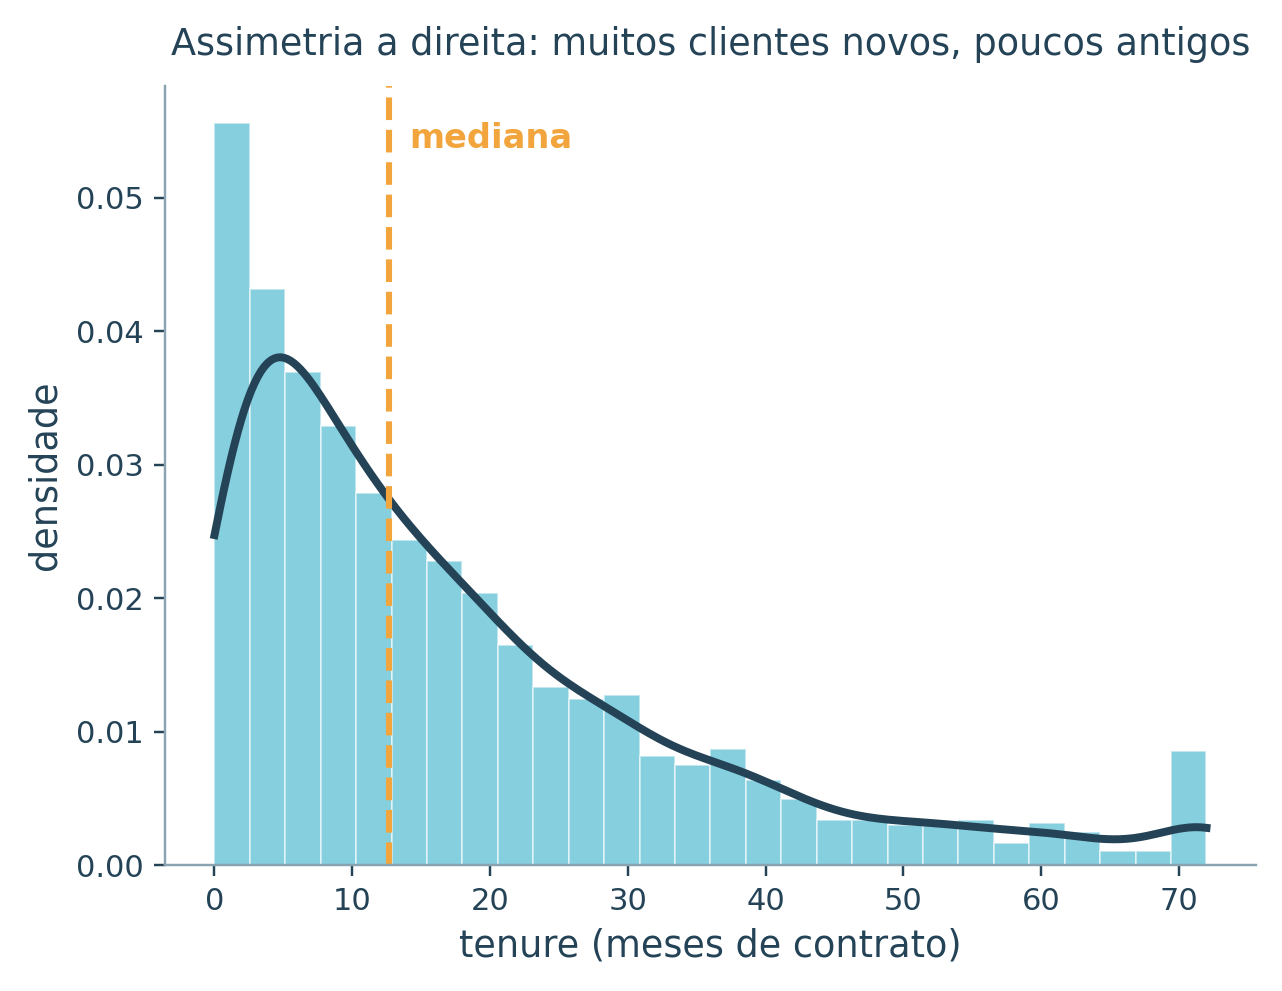

*Histograma + KDE de tenure: note a assimetria à direita (dados ilustrativos dos slides).*

## 4. Análise de Distribuições

**Perguntas que a EDA de distribuição responde:**
- Os dados são simétricos ou assimétricos?
- Há múltiplos picos (multimodal)?
- A relação entre média e mediana já denuncia a assimetria?
- Precisamos de transformação (log, Box-Cox) antes de modelar?

O histograma com curva de densidade (KDE) é a principal ferramenta aqui. A imagem acima mostra o
padrão esperado para `tenure`: muitos clientes novos (poucos meses de contrato) e uma cauda longa de
clientes antigos: **assimetria à direita**.

### Os três formatos clássicos

A posição relativa de **média** e **mediana** é o jeito mais rápido de diagnosticar a assimetria,
mesmo sem olhar o gráfico:

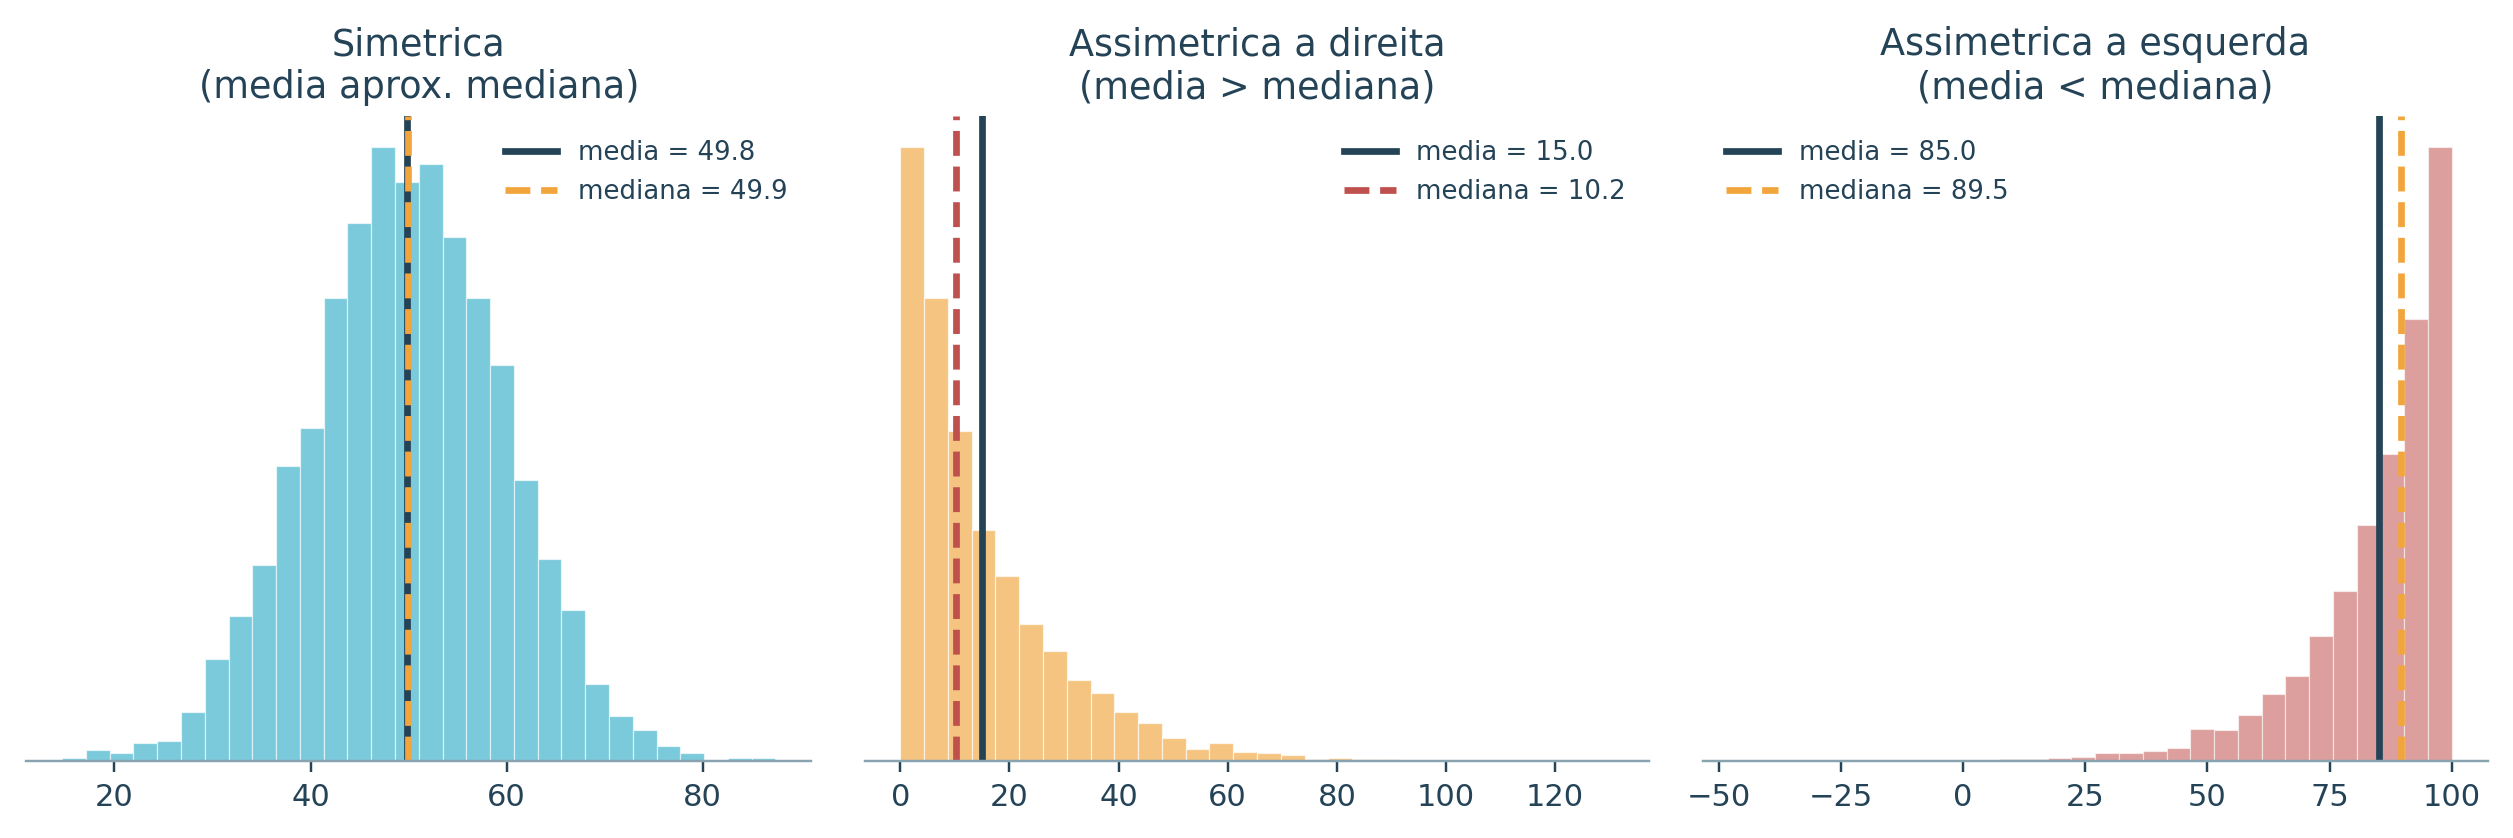

*Simétrica (média ≈ mediana) · Assimétrica à direita (média > mediana) · Assimétrica à esquerda (média < mediana).*

Agora é a sua vez: gere o mesmo gráfico para a variável `tenure` do nosso dataset, com as linhas de
média e mediana marcadas.

In [ ]:
media = df["tenure"].mean()
mediana = df["tenure"].median()

plt.figure(figsize=(8, 4.5))
sns.histplot(df["tenure"], kde=True, color=TEAL)
plt.axvline(media, color=NAVY, linewidth=2, label=f"média = {media:.1f}")
plt.axvline(mediana, color=GOLD, linewidth=2, linestyle="--", label=f"mediana = {mediana:.1f}")
plt.xlabel("tenure (meses de contrato)")
plt.legend()
plt.title("Distribuição de tenure")
plt.show()

print(f"média = {media:.2f} | mediana = {mediana:.2f}")
print("Média > mediana ->", media > mediana, "(esperado para assimetria à direita)")

**✏️ Exercício:** repita o gráfico acima para `MonthlyCharges` e para `TotalCharges`. Para cada uma,
anote: a distribuição é simétrica ou assimétrica? Em qual direção? Isso já é conteúdo do seu prompt
log, mesmo sem IA, registre a sua própria leitura antes de comparar com uma sugestão de LLM mais
adiante.

In [ ]:
# Espaço para o seu exercício: repita a análise para MonthlyCharges e TotalCharges
# sns.histplot(...)


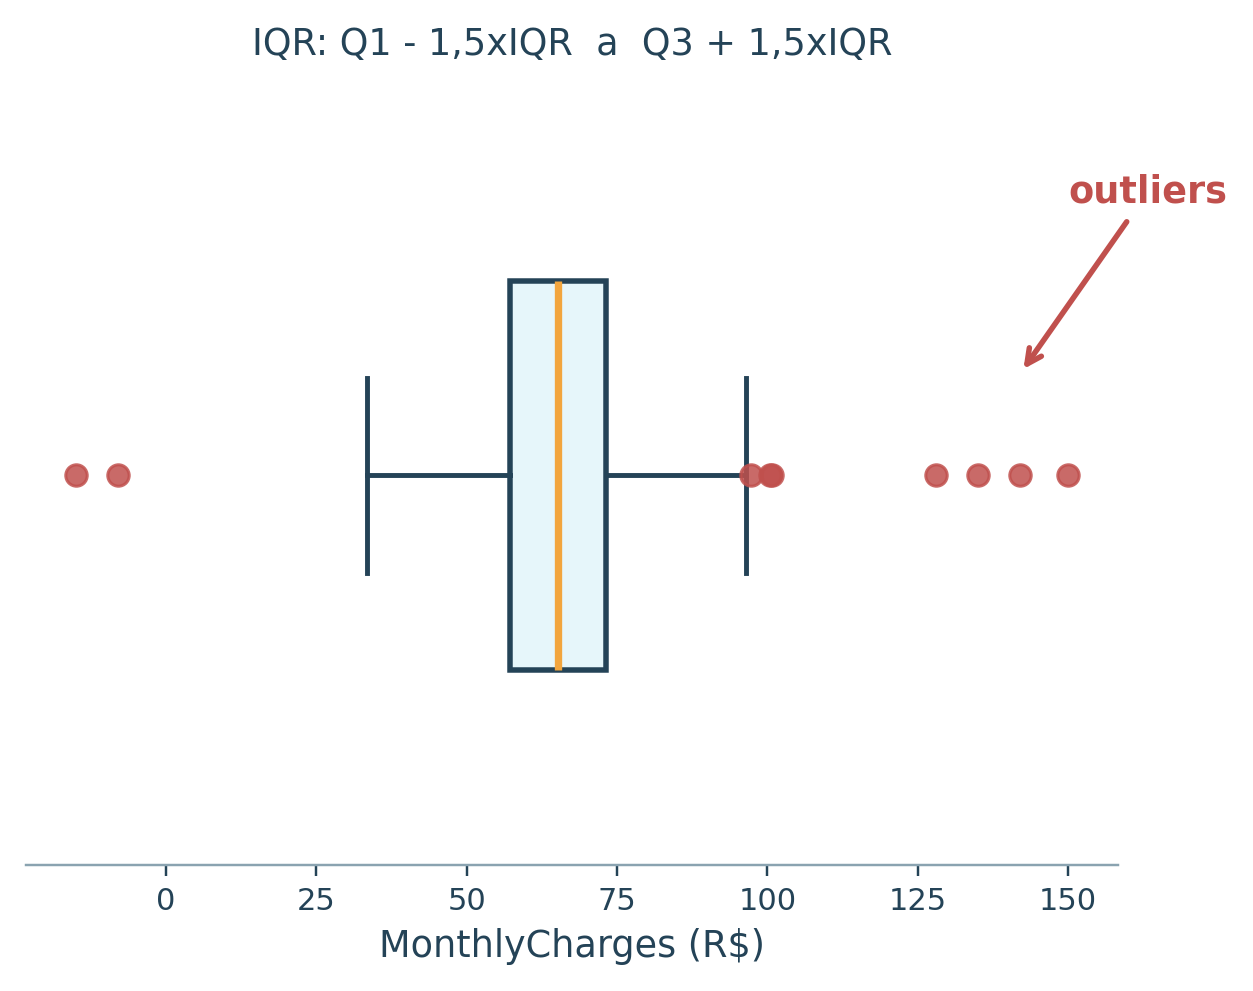

*Boxplot com outliers marcados em vermelho (dados ilustrativos dos slides).*

## 5. Detecção de Outliers com IQR

**IQR (Intervalo Interquartil) = Q3 − Q1.** Um ponto é considerado outlier se estiver fora do
intervalo:

$$[\,Q1 - 1{,}5 \times IQR \;,\; Q3 + 1{,}5 \times IQR\,]$$

Importante: a decisão de remover ou manter um outlier é **sempre uma decisão de negócio**, nunca
automática. Em preços de imóveis, um outlier costuma distorcer o modelo. Em detecção de fraude, o
outlier é exatamente o sinal que buscamos. No nosso caso de churn, um cliente com `tenure` baixo e
gasto alto pode ser um cliente insustentável, prestes a cancelar; vale investigar antes de excluir.

In [ ]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["MonthlyCharges"] < limite_inferior) | (df["MonthlyCharges"] > limite_superior)]
print(f"Limite inferior: {limite_inferior:.2f} | Limite superior: {limite_superior:.2f}")
print(f"{len(outliers)} outliers encontrados em MonthlyCharges")

plt.figure(figsize=(8, 3.5))
sns.boxplot(x=df["MonthlyCharges"], color=TEAL)
plt.title("Boxplot de MonthlyCharges")
plt.show()

**✏️ Exercício:** repita a análise de outliers para `tenure` e para `TotalCharges` (cuidado com os
valores ausentes nesta última; trataremos isso na Seção 7).

In [ ]:
# Espaço para o seu exercício: repita a detecção de outliers (IQR) para tenure e TotalCharges


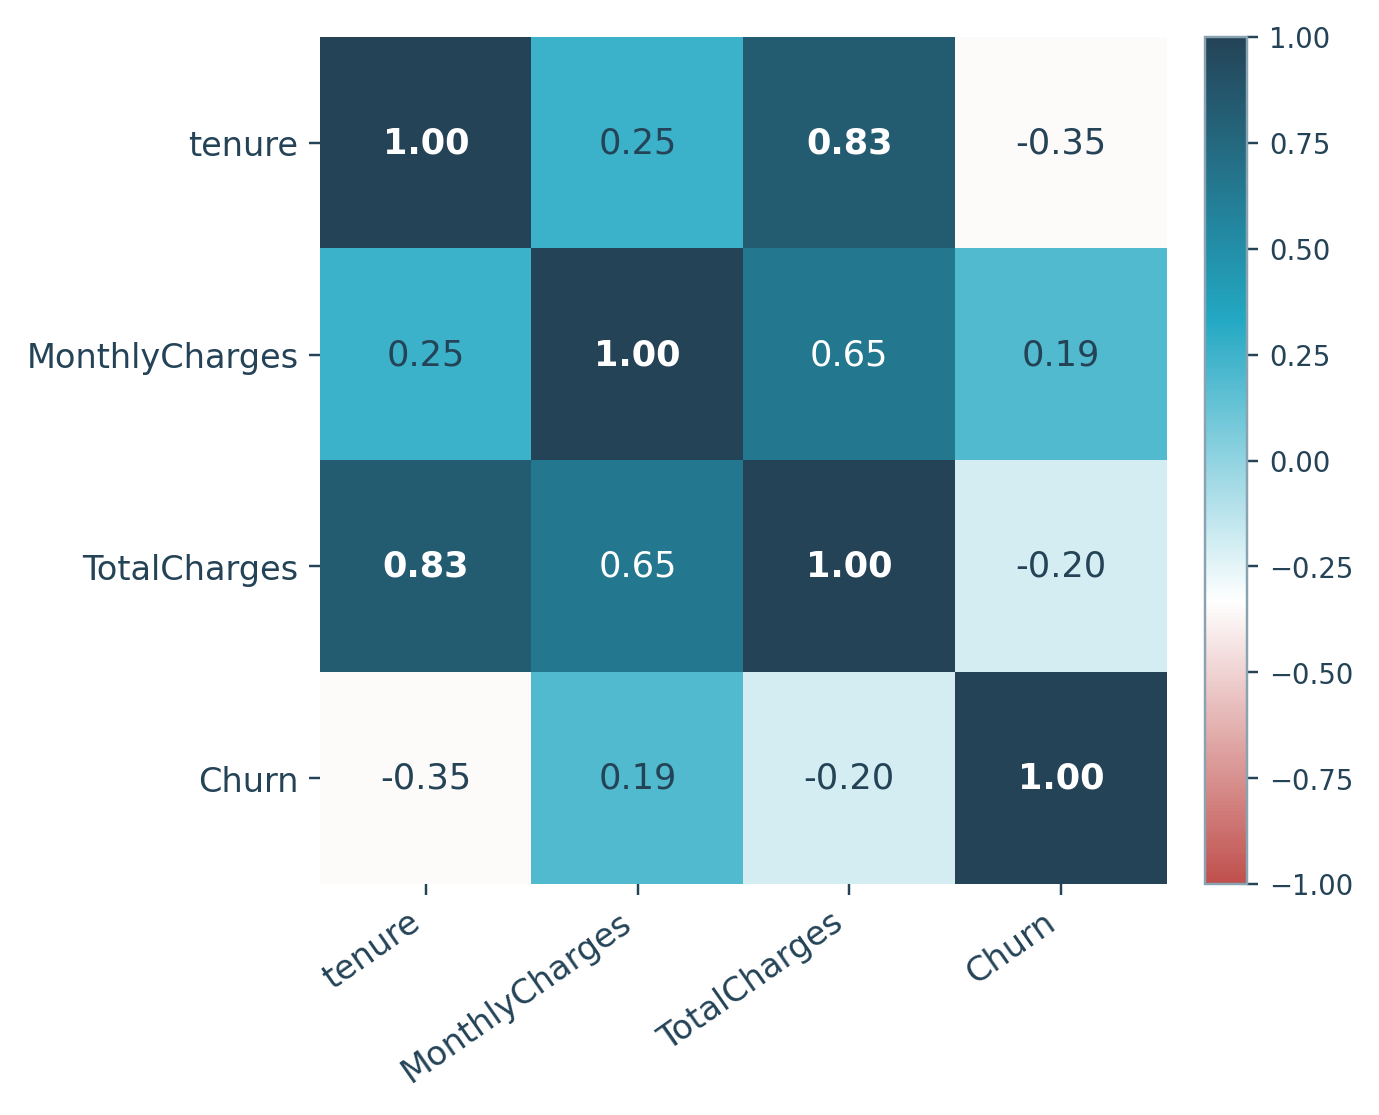

*Matriz de correlação entre tenure, MonthlyCharges, TotalCharges e Churn (dados ilustrativos dos slides).*

## 6. Correlação entre Variáveis

O heatmap é o "resumo executivo" de todas as correlações do dataset de uma vez. Na imagem acima,
repare que `tenure` e `TotalCharges` têm correlação muito alta (≈0,83): faz sentido, já que
`TotalCharges` é, grosso modo, `tenure × MonthlyCharges`. Correlação alta entre features (multicolinearidade)
pode confundir modelos lineares; vale considerar remover uma das duas ou combiná-las em uma nova feature.

⚠️ **Correlação não é causalidade**, mas é um ótimo ponto de partida para Feature Engineering.

| Faixa de r (Pearson) | Interpretação |
|---|---|
| 0,00 a ±0,19 | Muito fraca ou nula |
| ±0,20 a ±0,39 | Fraca |
| ±0,40 a ±0,59 | Moderada |
| ±0,60 a ±0,79 | Forte |
| ±0,80 a ±1,00 | Muito forte |

In [ ]:
# Transformamos Churn em 0/1 apenas para poder incluí-la no cálculo de correlação
df_corr = df.copy()
df_corr["Churn_num"] = (df_corr["Churn"] == "Yes").astype(int)

numericas = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]]
corr = numericas.corr()  # Pearson por padrão; use method="spearman" para relações não lineares

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()

corr

## 7. Feature Engineering com IA Generativa

Agora entramos no coração da unidade: criar novas variáveis a partir das existentes, usando um LLM
como copiloto de brainstorming. A metodologia é o **PBL Aumentado**: a IA sugere, você audita, você
implementa, nesta ordem, sempre.

### O prompt (use no ChatGPT, Claude ou Gemini de sua escolha)

```
Atue como um Cientista de Dados Sênior especialista em TELECOM.
Dataset: tenure, MonthlyCharges, TotalCharges, Contract, PaperlessBilling, PaymentMethod.
Objetivo: prever CHURN.

Crie 5 NOVAS FEATURES que ajudem a prever churn. Para cada uma, explique: nome e fórmula,
por que ajuda, código Pandas, e sinalize risco de DATA LEAKAGE.
```

### Checklist do Auditor de Features

Aplique este checklist a **cada** feature sugerida pela IA, nunca confie cegamente:

1. Os dados para calcular a feature **existem**? (Se não → alucinação, descarte.)
2. A feature tem **sentido de negócio**? (Um gestor concordaria?)
3. Não há **data leakage**? (Não usa informação do futuro ou do conjunto de teste.)
4. É **computacionalmente viável**? (Não vai explodir memória em produção?)

Abaixo, implementamos 3 features de exemplo (equivalentes às sugeridas no slide *"Brainstorming de
Features com IA"*) já auditadas. Depois de rodar o prompt acima com sua dupla, substitua ou adicione
as features que vocês validaram.

In [ ]:
df_feat = df.copy()

# Feature 1: gasto médio mensal real (cuidado com tenure=0 -> divisão por zero)
df_feat["avg_monthly_spend"] = df_feat["TotalCharges"] / df_feat["tenure"].replace(0, np.nan)

# Feature 2: segmento de alto risco (mensalidade alta + contrato mensal)
df_feat["is_high_risk_segment"] = (
    (df_feat["MonthlyCharges"] > 70) & (df_feat["Contract"] == "Month-to-month")
).astype(int)

# Feature 3: razao tenure / gasto (quanto tempo de casa por real gasto)
df_feat["tenure_to_charge_ratio"] = df_feat["tenure"] / df_feat["MonthlyCharges"]

df_feat[["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend",
         "is_high_risk_segment", "tenure_to_charge_ratio"]].head()

⚠️ **Risco de data leakage:** se `tenure_to_charge_ratio` (ou qualquer feature parecida) fosse
calculada usando uma **média global** do dataset inteiro (por exemplo, normalizando pela média de
`MonthlyCharges` de todos os clientes), o modelo "veria" informação do conjunto de teste durante o
treino. A regra de ouro (Seção 9): qualquer estatística agregada (média, desvio padrão, encoding) deve
ser calculada **apenas no conjunto de treino**, depois de fazer o split.

**✏️ Exercício em dupla: Prompt Battle.** Cada integrante escreve um prompt diferente para o mesmo
objetivo. Rodem os dois prompts, apliquem o Checklist do Auditor às sugestões de cada um, e decidam:
qual prompt gerou features mais específicas, seguras e com menos alucinação?

In [ ]:
# Espaço para as features que foi validada com o Checklist do Auditor


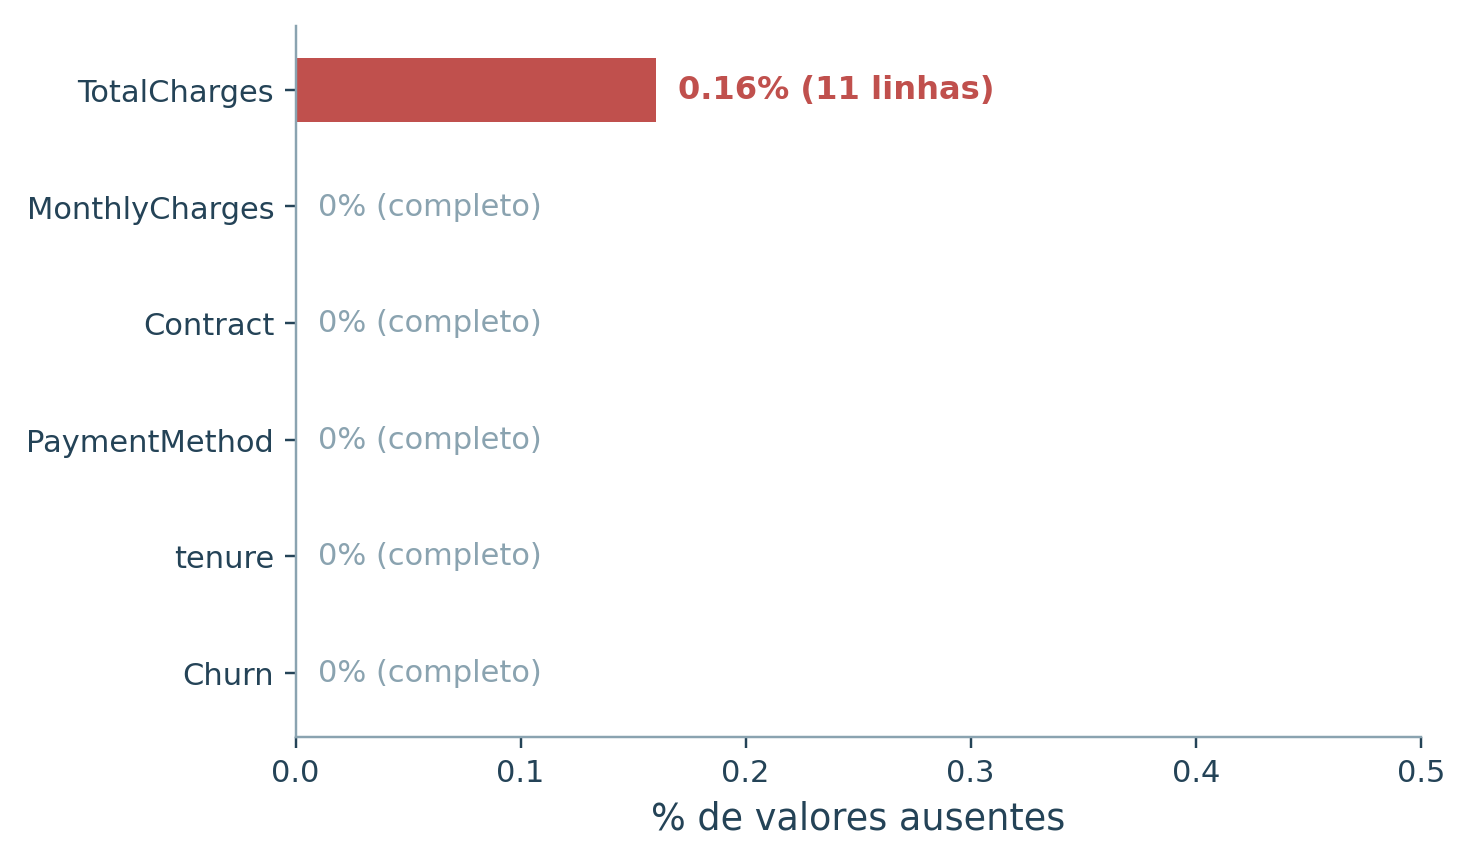

*% de valores ausentes por coluna no dataset de referência (dados ilustrativos dos slides).*

## 8. Pré-processamento

### 8.1 Dados ausentes

No nosso dataset real, `TotalCharges` tem valores ausentes exatamente para os clientes
com `tenure = 0`. Isso **não é erro**, é informação: são clientes novíssimos, que ainda não geraram
uma cobrança total. Pergunte sempre: *por que está ausente? É aleatório ou sistemático?*

In [ ]:
print("Valores ausentes por coluna:")
print(df_feat.isna().sum())

# Estratégia: preencher com 0, já que sabemos a causa (clientes novos, tenure=0)
imputer_simples = SimpleImputer(strategy="constant", fill_value=0)
df_feat["TotalCharges"] = imputer_simples.fit_transform(df_feat[["TotalCharges"]])

# Alternativa mais sofisticada (comente a linha acima e use esta se preferir):
# imputer_knn = KNNImputer(n_neighbors=5)
# df_feat[["TotalCharges"]] = imputer_knn.fit_transform(df_feat[["TotalCharges"]])

# Atenção: "avg_monthly_spend" foi calculada ANTES da imputação (Seção 7) e depende de
# TotalCharges, então também ficou com NaN nos clientes com tenure=0. Como acabamos de
# tratar a causa raiz, é preciso recalcular a feature derivada, não só a coluna original.
df_feat["avg_monthly_spend"] = df_feat["TotalCharges"] / df_feat["tenure"].replace(0, np.nan)
df_feat["avg_monthly_spend"] = df_feat["avg_monthly_spend"].fillna(0)

print("\nValores ausentes após imputação:")
print(df_feat[["TotalCharges", "avg_monthly_spend"]].isna().sum())

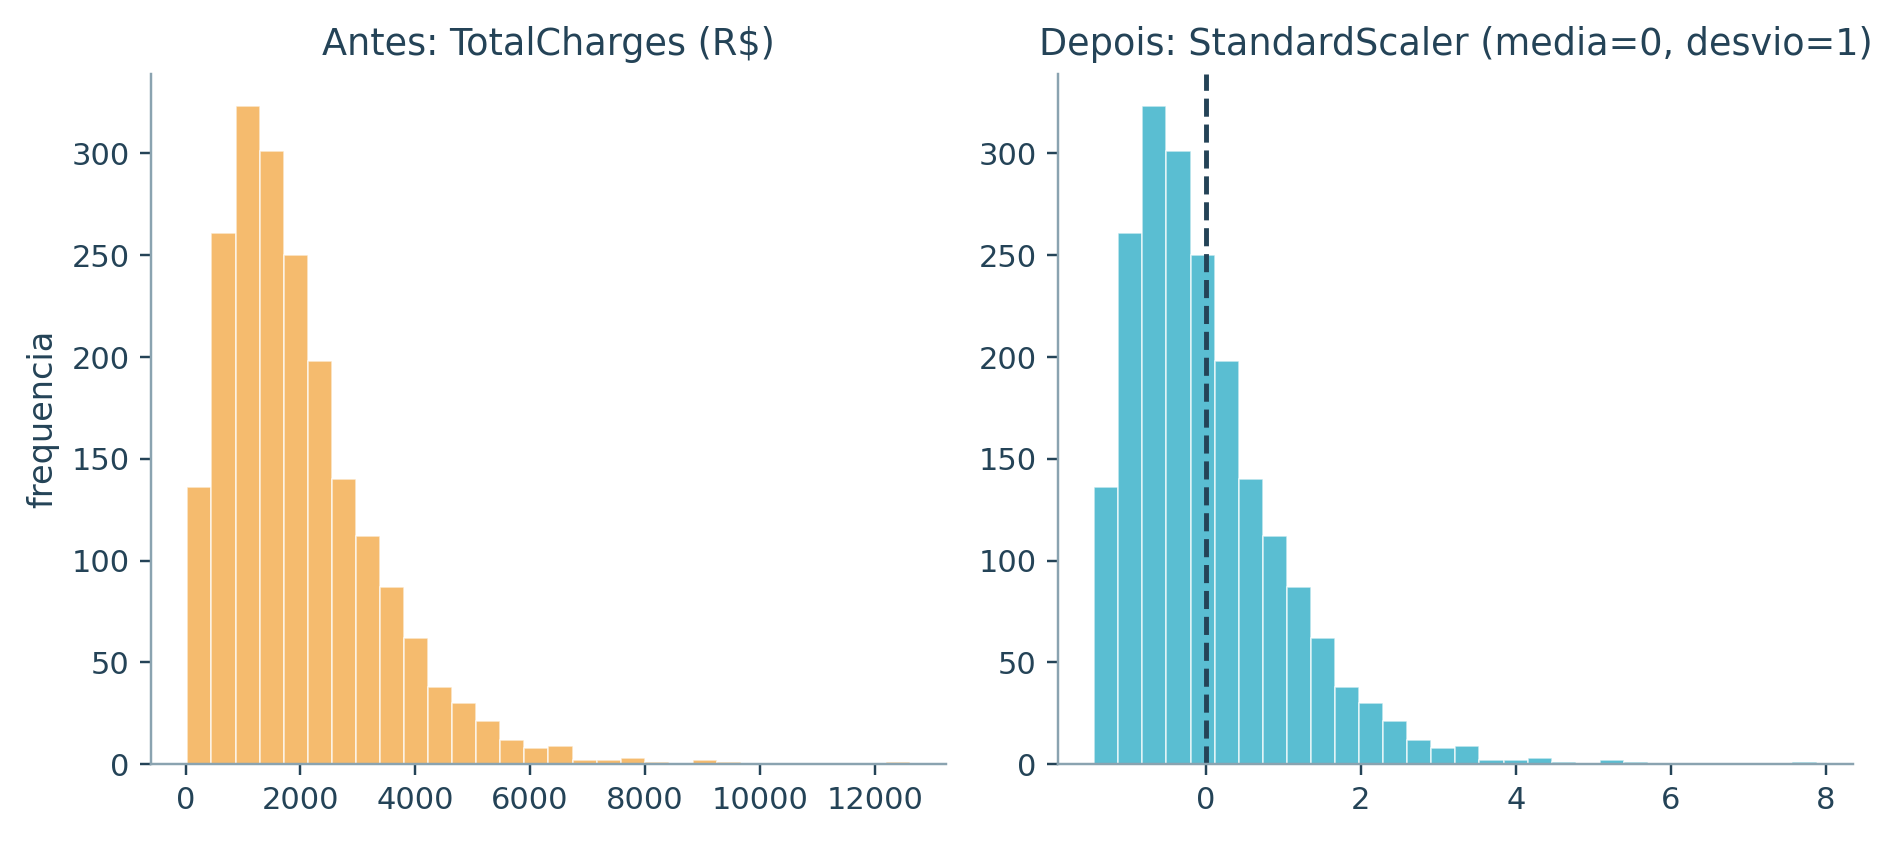

*TotalCharges antes e depois do StandardScaler (dados ilustrativos dos slides).*

### 8.2 Escalonamento

- **StandardScaler (padronização):** transforma para média 0 e desvio padrão 1: `z = (x - μ) / σ`.
  Ideal para regressão, SVM, PCA; mais robusto a outliers.
- **MinMaxScaler (normalização):** comprime para o intervalo [0, 1]. Ideal para redes neurais e k-NN;
  sensível a outliers.

### 8.3 Codificação categórica

| Técnica | Quando usar | Cuidado |
|---|---|---|
| One-Hot Encoding | Categorias nominais (sem ordem) | Aumenta dimensionalidade |
| Ordinal Encoding | Categorias com ranking natural | Preserva a ordem |
| Target Encoding | Alta cardinalidade | ⚠️ Alto risco de data leakage se feito antes do split |
| Binary Encoding | Cardinalidade muito alta (CEPs, IDs) | Reduz colunas com eficiência |

🥇 **Regra de ouro:** `fit()` apenas no **TREINO**; `transform()` no treino **e** no teste. Nunca use
`fit()` no dataset inteiro: é a forma mais comum de data leakage silencioso.

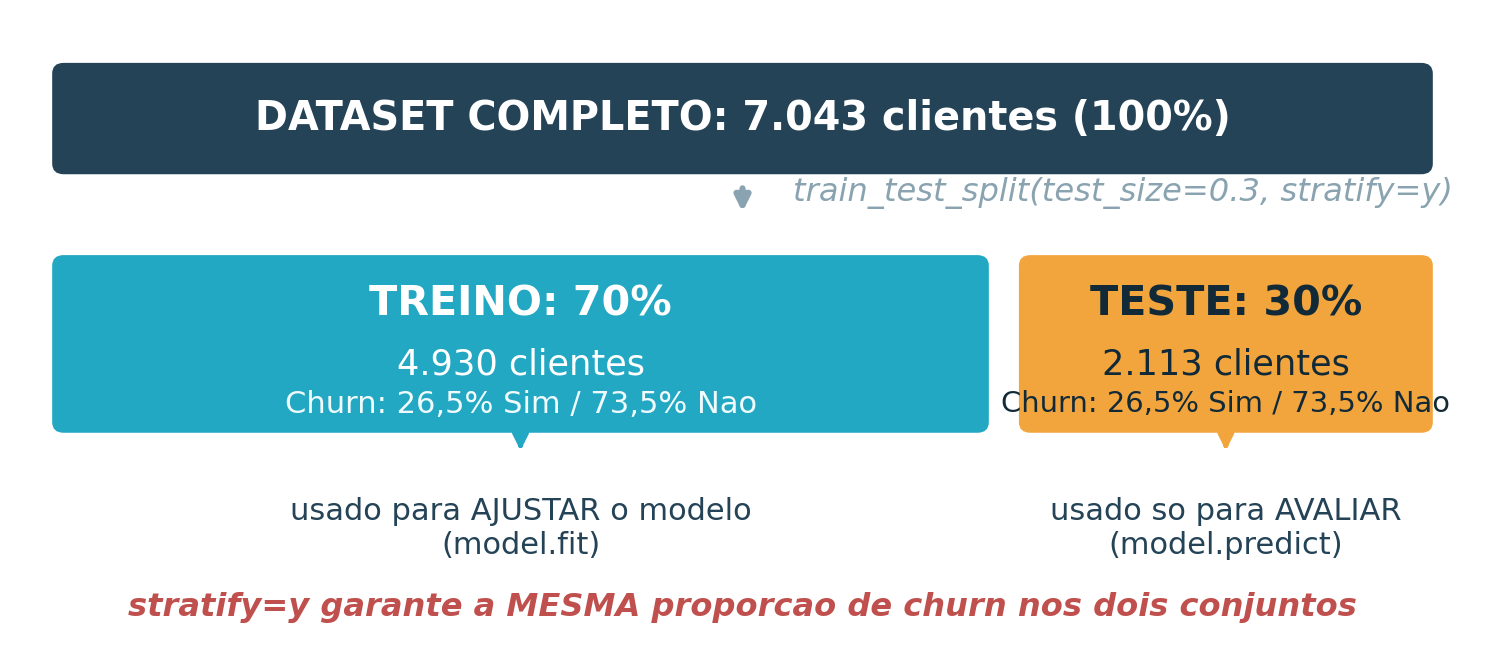

*O conjunto de teste fica "trancado": o modelo nunca o vê durante o treino, só na hora de avaliar.*

## 9. Separando Treino e Teste: Antes de Escalonar e Codificar

Esta é a **regra de ouro** da unidade: separe treino e teste **antes** de calcular qualquer estatística
(média, desvio padrão, encoding) que dependa dos dados. Testar o modelo com os mesmos dados do treino
é como dar a prova com as respostas ao aluno.

O parâmetro `stratify=y` garante que a proporção de churn seja a mesma nos dois conjuntos; sem isso,
por azar, o conjunto de teste poderia ficar com muito mais (ou muito menos) casos de churn do que o
treino, distorcendo a avaliação.

In [ ]:
features_numericas = ["tenure", "MonthlyCharges", "TotalCharges",
                       "avg_monthly_spend", "tenure_to_charge_ratio", "is_high_risk_segment"]
features_categoricas = ["Contract", "PaperlessBilling", "PaymentMethod"]

X = df_feat[features_numericas + features_categoricas].copy()
y = (df_feat["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Proporção de churn:", y_train.mean().round(3))
print("Teste: ", X_test.shape, " | Proporção de churn:", y_test.mean().round(3))

In [ ]:
# Agora sim: fit() SÓ no treino, transform() no treino e no teste

scaler = StandardScaler()
X_train[features_numericas] = scaler.fit_transform(X_train[features_numericas])
X_test[features_numericas] = scaler.transform(X_test[features_numericas])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_encoded = encoder.fit_transform(X_train[features_categoricas])
test_encoded = encoder.transform(X_test[features_categoricas])

encoded_cols = encoder.get_feature_names_out(features_categoricas)
X_train_final = pd.concat([
    X_train[features_numericas].reset_index(drop=True),
    pd.DataFrame(train_encoded, columns=encoded_cols)
], axis=1)
X_test_final = pd.concat([
    X_test[features_numericas].reset_index(drop=True),
    pd.DataFrame(test_encoded, columns=encoded_cols)
], axis=1)

X_train_final.head()

## 10. E o Modelo?

Perceba que `X_train_final` e `X_test_final` já estão prontos: escalonados, codificados, sem dados
ausentes. É exatamente o ponto de partida que um modelo de Machine Learning precisa.

**Mas ainda não vamos treinar nada.** Nesta tarefa, o entregável é o processo completo de EDA e Feature
Engineering bem feito, não a performance de um modelo. Guarde este notebook: a partir da próxima aula,
vocês vão continuar exatamente daqui, treinando e comparando modelos (primeiro de regressão, depois
classificação e ensembles) em cima das bases que vocês mesmos prepararam agora.

## Checklist final da tarefa

- [ ] Carreguei o dataset real e explorei shape, tipos e valores ausentes.
- [ ] Identifiquei e corrigi o problema de tipo em `TotalCharges` (texto -> numérico).
- [ ] Gerei histogramas (com média/mediana) para pelo menos duas variáveis numéricas.
- [ ] Apliquei o método IQR para detectar outliers em pelo menos duas variáveis.
- [ ] Li o heatmap de correlação e expliquei, com minhas palavras, o que a maior correlação significa.
- [ ] Apliquei o prompt de brainstorming de features a um LLM e documentei o prompt usado.
- [ ] Usei o Checklist do Auditor e implementei pelo menos 3 features validadas.
- [ ] Tratei os dados ausentes reais de `TotalCharges`, apliquei encoding e escalonamento **depois** do split.
- [ ] Separei treino e teste com `stratify=y` e confirmei que a proporção de churn ficou parecida nos dois.
- [ ] Documentei os prompts usados (prompt log) para a entrega do Trabalho Orientado.

